In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix



c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- SETUP PERCORSI ---
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))
from project_paths import get_paths

paths = get_paths(ROOT)

# --- CONFIGURAZIONE ---
TEST_DATA_PATH = paths.data_processed / "test_120k_ht.parquet"
# ⚠️ INSERISCI QUI IL NOME DELLA CARTELLA DEL TUO CHECKPOINT MIGLIORE
BEST_CHECKPOINT = paths.checkpoints / "teacher_bert_large_llrd" / "checkpoint-6000" 
MODEL_BASE_NAME = "bert-large-uncased"



In [3]:
from transformers import DataCollatorWithPadding


# --- FUNZIONI DI UTILITÀ ---
def load_test_data(path):
    print(f"📂 Caricamento Test Set da: {path}")
    ds = load_dataset("parquet", data_files=str(path))["train"]
    # Rinomina label -> labels se necessario
    if "label" in ds.column_names:
        ds = ds.rename_column("label", "labels")
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds


# --- 1. SETUP TOKENIZER & COLLATOR (Fondamentale per il padding!) ---
# Carichiamo il tokenizer base (serve per sapere quale token usare per il padding)
tokenizer = AutoTokenizer.from_pretrained("bert-large-uncased")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# --- FUNZIONE GET_PREDICTIONS CORRETTA E SICURA ---
def get_predictions(model, dataset):
    """Esegue inferenza pura. Rimuove le label per evitare crash sulla Loss."""
    print("🔮 Avvio Inferenza...")
    
    # 1. Salviamo le label vere in una variabile locale (ci servono per le metriche!)
    #    Convertiamo in numpy array per sicurezza
    true_labels = np.array(dataset["labels"])
    
    # 2. Creiamo una copia del dataset SENZA la colonna 'labels'
    #    In questo modo il Trainer NON proverà a calcolare la loss e non crasherà.
    dataset_no_labels = dataset.remove_columns(["labels"])
    
    # 3. Setup Trainer (solo per gestire il batching e il padding)
    trainer = Trainer(
        model=model, 
        data_collator=data_collator # Ricorda: data_collator deve essere definito prima!
    )
    
    # 4. Predict sul dataset "pulito"
    output = trainer.predict(dataset_no_labels)
    
    logits = output.predictions
    
    # Gestione output (alcuni modelli tornano tuple)
    if isinstance(logits, tuple): 
        logits = logits[0]
        
    # 5. Calcolo probabilità (Sigmoide)
    #    1 / (1 + e^-x)
    probs = 1 / (1 + np.exp(-logits))
    
    # 6. Soglia a 0.5 per ottenere 0 o 1
    #    Flattening (.reshape(-1)) per avere un array piatto [0, 1, 1, 0...]
    preds = (probs > 0.5).astype(int).reshape(-1)
    
    # Restituiamo le label vere (salvate prima) e le predizioni
    return true_labels, preds, probs

def print_metrics(labels, preds, probs, name):
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    try: auc = roc_auc_score(labels, probs)
    except: auc = 0.5
    
    print(f"\n📊 --- METRICHE: {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall:    {r:.4f}")
    print(f"AUC:       {auc:.4f}")
    return {"accuracy": acc, "f1": f1, "precision": p, "recall": r, "auc": auc}

def plot_confusion_matrix(labels, preds, title, ax):
    cm = confusion_matrix(labels, preds)
    # Normalizziamo per vedere le percentuali
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_ylabel('Vero (Label)')
    ax.set_xlabel('Predetto')
    ax.set_xticklabels(['Non-Spoiler', 'Spoiler'])
    ax.set_yticklabels(['Non-Spoiler', 'Spoiler'])



📂 Caricamento Test Set da: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\data\processed\test_120k_ht.parquet

🏗️ Caricamento Modello FINE-TUNED (C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\teacher_bert_large_llrd\checkpoint-6000)...
🔮 Avvio Inferenza...



🏗️ Caricamento Modello BASE (bert-large-uncased)...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🔮 Avvio Inferenza...



📊 --- METRICHE: BERT BASE (Untrained) ---
Accuracy:  0.2637
F1 Score:  0.4162
Precision: 0.2629
Recall:    0.9981
AUC:       0.5270

📊 --- METRICHE: TEACHER FINE-TUNED ---
Accuracy:  0.7623
F1 Score:  0.5863
Precision: 0.5407
Recall:    0.6404
AUC:       0.8060


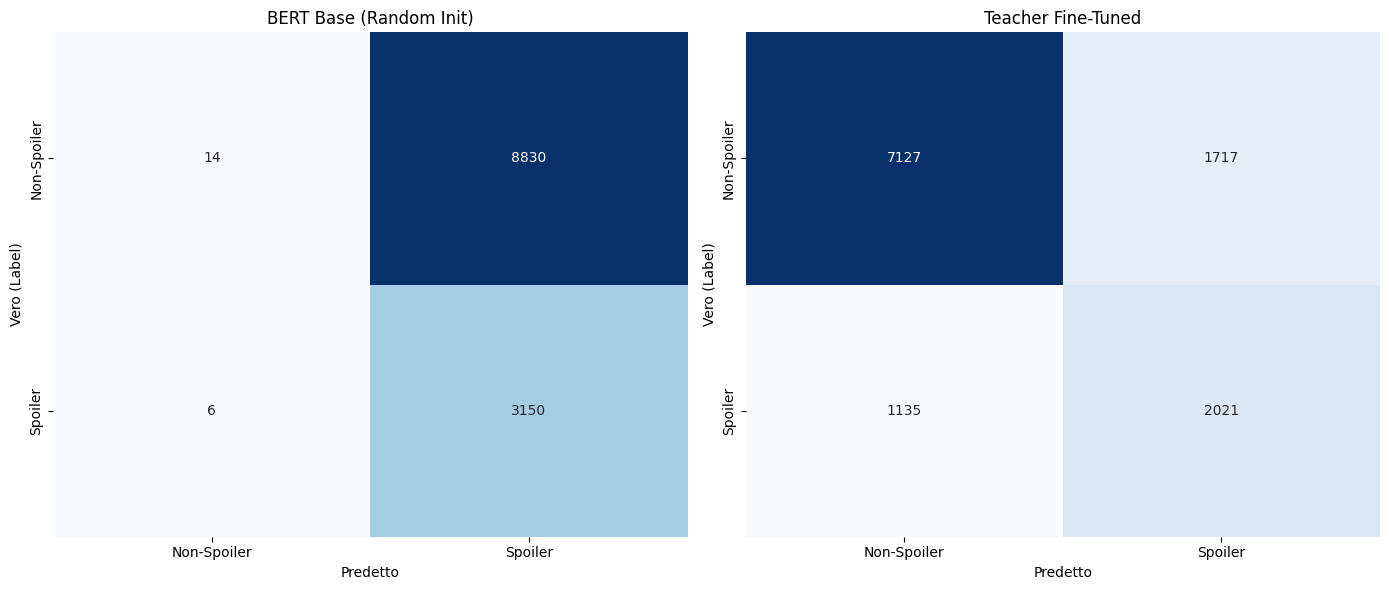

AttributeError: 'ProjectPaths' object has no attribute 'reports'

In [ ]:
# --- MAIN ---

# 1. Carica Dati
test_ds = load_test_data(TEST_DATA_PATH)

# 3. Modello B: TEACHER FINE-TUNED
print(f"\n🏗️ Caricamento Modello FINE-TUNED ({BEST_CHECKPOINT})...")
model_ft = AutoModelForSequenceClassification.from_pretrained(BEST_CHECKPOINT, num_labels=1)
labels_ft, preds_ft, probs_ft = get_predictions(model_ft, test_ds)

# 2. Modello A: BERT BASE (Non addestrato sul task)
# Nota: I pesi del classificatore saranno inizializzati a caso!
print(f"\n🏗️ Caricamento Modello BASE ({MODEL_BASE_NAME})...")
model_base = AutoModelForSequenceClassification.from_pretrained(MODEL_BASE_NAME, num_labels=1)
labels_base, preds_base, probs_base = get_predictions(model_base, test_ds)



# 4. Confronto Numerico
metrics_base = print_metrics(labels_base, preds_base, probs_base, "BERT BASE (Untrained)")
metrics_ft = print_metrics(labels_ft, preds_ft, probs_ft, "TEACHER FINE-TUNED")

# 5. Visualizzazione Matrici di Confusione
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_confusion_matrix(labels_base, preds_base, "BERT Base (Random Init)", axes[0])
plot_confusion_matrix(labels_ft, preds_ft, "Teacher Fine-Tuned", axes[1])

plt.tight_layout()
plt.show()



In [5]:
# Salva grafico per il report
fig.savefig("teacher_comparison_matrix.png")
print("\n✅ Grafico salvato in reports/figures/teacher_comparison_matrix.png")


✅ Grafico salvato in reports/figures/teacher_comparison_matrix.png
